# Corpus Analysis with spaCy

## 1. Preparing Files

Each `album` file contains all songs from that album. The individual songs are split by 4 empty lines. The following code block splits the album files into individual .txt files for each song. 

In [12]:
import os

# Split album files into individual song lyrics files.
def split_txt_file(input_file, album):
    output_directory = 'data/txt_lyrics'
    os.makedirs(output_directory, exist_ok=True)

    with open(input_file, 'r', encoding='utf-8') as file:
        content = file.read()
    songs = content.split('\n\n\n\n') # Individual songs are separated by 4 empty lines.

    for i, song in enumerate(songs):
        output_file = os.path.join(output_directory, f"{album}_{i + 1}.txt")
        with open(output_file, 'w', encoding='utf-8') as output:
            output.write(song.strip())

albums = [('data/albums/album_1.txt', 'nightmares'),
('data/albums/album_2.txt', 'ruin'),
('data/albums/album_3.txt', 'hollow_crown'),
('data/albums/album_4.txt', 'here_and_now'),
('data/albums/album_5.txt', 'daybreaker'),
('data/albums/album_6.txt', 'lost'),
('data/albums/album_7.txt', 'abandoned'),
('data/albums/album_8.txt', 'holy_hell'),
('data/albums/album_9.txt', 'wish_to_exist'),
('data/albums/album_10.txt', 'classic_symptoms')]

for input_file, album in albums:
    split_txt_file(input_file, album)

### Installing, Importing and Preprocessing

In [2]:
import spacy
import pandas as pd
import plotly.express as px

pd.options.mode.chained_assignment = None

!spacy download en_core_web_sm

from spacy import displacy

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [20]:
# Create a dataframe from the .txt files
lyrics = []
file_names = []

for file in os.listdir('data/txt_lyrics'):
    if file.endswith('.txt'):
        lyrics.append(open('data/txt_lyrics' + '/' + file, 'r', encoding='utf-8').read())
        file_names.append(file)

d = {'filename':file_names,'text':lyrics}

lyrics_df = pd.DataFrame(d)
lyrics_df['text'] = lyrics_df['text'].str.replace('\n+', ' ', regex=True).str.strip()
lyrics_df.head()

,filename,text
0,here_and_now_9.txt,Burn everything you have And leave it all behi...
1,abandoned_11.txt,"As above, so below. Dismantled piece by piece,..."
2,classic_symptoms_1.txt,"We, we wanna swim the deepest depths of oblivi..."
3,abandoned_10.txt,"There is no endgame, So whisper the truth and ..."
4,here_and_now_8.txt,"You've done this to yourself or so, so it seem..."


In [135]:
# Merge Metadata.
metadata_df = pd.read_csv('metadata.csv')

# Remove .txt from the filenames.
lyrics_df['filename'] = lyrics_df['filename'].str.replace('.txt', '', regex=True) 

# The names in 'filename' column in Metadata file match up with the names in 'filename' column in dataframe.
final_lyrics_df = metadata_df.merge(lyrics_df,on='filename')
final_lyrics_df.head()

,filename,title,album,year,text
0,nightmares_1,To the death,Nightmares,2006,When In Troy Do as the Greeks do This is treac...
1,nightmares_2,You Don’t Walk Away From Dismemberment,Nightmares,2006,I will spill blood On your filthy princess whi...
2,nightmares_3,Minesweeper,Nightmares,2006,Been searching all day For the answers Do you ...
3,nightmares_4,They'll Be Hanging Us Tonight,Nightmares,2006,Raid all the liquor stores Kidnap the kids Thi...
4,nightmares_5,This Confession Means Nothing,Nightmares,2006,I close my eyes And hold you in my arms Despit...


## 2. Text Enrichment

### Creating Doc objects

In [189]:
# Load the spaCy model.
nlp = spacy.load('en_core_web_sm')

def remove_punc(text):
    punctuation = '!@#$%^&*()_-+={}[]:;"\'|<>,.?/~`'
    return ''.join(character for character in text if character not in punctuation)

def process_text(text):
    # Remove punctuation and convert to lowercase.
    cleaned_text = remove_punc(text).lower()
    return nlp(cleaned_text)

# Create Doc objects from cleaned text and store in the 'doc' column.
final_lyrics_df['doc'] = final_lyrics_df['text'].apply(process_text)

### Tokenisation

In [187]:
def get_token(doc):
    return [(token.text) for token in doc]

final_lyrics_df['tokens'] = final_lyrics_df['doc'].apply(get_token)

### Lemmatisation

In [185]:
def get_lemma(doc):
    return [(token.lemma_) for token in doc]

final_lyrics_df['lemmas'] = final_lyrics_df['doc'].apply(get_lemma)

### Part of Speech Tagging


In [191]:
def get_pos(doc):
    return [(token.pos_, token.tag_) for token in doc]

final_lyrics_df['POS'] = final_lyrics_df['doc'].apply(get_pos)

### Named Entity Recognition

In [150]:
def extract_named_entities(doc):
    return [ent.label_ for ent in doc.ents]

final_lyrics_df['Named_Entities'] = final_lyrics_df['doc'].apply(extract_named_entities)
final_lyrics_df['Named_Entities']

0                                                     []
1                                           [TIME, TIME]
2                          [DATE, GPE, TIME, TIME, TIME]
3                                           [DATE, TIME]
4                                                     []
                             ...                        
110           [DATE, DATE, DATE, DATE, DATE, DATE, DATE]
111               [CARDINAL, PERSON, CARDINAL, CARDINAL]
112    [CARDINAL, CARDINAL, CARDINAL, CARDINAL, QUANT...
113                                               [TIME]
114                                             [PERSON]
Name: Named_Entities, Length: 115, dtype: object

In [152]:
def extract_named_entities(doc):
    return [ent for ent in doc.ents]
    
final_lyrics_df['NE_Words'] = final_lyrics_df['doc'].apply(extract_named_entities)
final_lyrics_df['NE_Words']

0                                                     []
1                                 [(tonight), (tonight)]
2      [(all, day), (us), (tonight), (this, night), (...
3                            [(this, nights), (tonight)]
4                                                     []
                             ...                        
110    [(tomorrow), (another, day), (tomorrow), (anot...
111         [(thousand), (wolf), (thousand), (thousand)]
112    [(two), (three), (four), (five), (six, feet), ...
113                                    [(eleven, hours)]
114                                       [(armageddon)]
Name: NE_Words, Length: 115, dtype: object

In [195]:
final_lyrics_df.head()

,filename,title,album,year,text,doc,tokens,lemmas,POS,Named_Entities,NE_Words
0,nightmares_1,To the death,Nightmares,2006,When In Troy Do as the Greeks do This is treac...,"(when, in, troy, do, as, the, greeks, do, this...","[when, in, troy, do, as, the, greeks, do, this...","[when, in, troy, do, as, the, greek, do, this,...","[(SCONJ, WRB), (ADP, IN), (NOUN, NN), (VERB, V...",[],[]
1,nightmares_2,You Don’t Walk Away From Dismemberment,Nightmares,2006,I will spill blood On your filthy princess whi...,"(i, will, spill, blood, on, your, filthy, prin...","[i, will, spill, blood, on, your, filthy, prin...","[I, will, spill, blood, on, your, filthy, prin...","[(PRON, PRP), (AUX, MD), (VERB, VB), (NOUN, NN...","[TIME, TIME]","[(tonight), (tonight)]"
2,nightmares_3,Minesweeper,Nightmares,2006,Been searching all day For the answers Do you ...,"(been, searching, all, day, for, the, answers,...","[been, searching, all, day, for, the, answers,...","[be, search, all, day, for, the, answer, do, y...","[(AUX, VBN), (VERB, VBG), (DET, DT), (NOUN, NN...","[DATE, GPE, TIME, TIME, TIME]","[(all, day), (us), (tonight), (this, night), (..."
3,nightmares_4,They'll Be Hanging Us Tonight,Nightmares,2006,Raid all the liquor stores Kidnap the kids Thi...,"(raid, all, the, liquor, stores, kidnap, the, ...","[raid, all, the, liquor, stores, kidnap, the, ...","[raid, all, the, liquor, store, kidnap, the, k...","[(VERB, VB), (DET, PDT), (DET, DT), (NOUN, NN)...","[DATE, TIME]","[(this, nights), (tonight)]"
4,nightmares_5,This Confession Means Nothing,Nightmares,2006,I close my eyes And hold you in my arms Despit...,"(i, close, my, eyes, and, hold, you, in, my, a...","[i, close, my, eyes, and, hold, you, in, my, a...","[I, close, my, eye, and, hold, you, in, my, ar...","[(PRON, PRP), (VERB, VBP), (PRON, PRP$), (NOUN...",[],[]


In [197]:
# Download Enriched Dataset
final_lyrics_df.to_csv('Architects_Lyrics_with_spaCy_tags.csv')

## 3. Analysis

### Part of Speech Analysis

In this section, part-of-speech tags extracted by spaCy are used to investigate the research question: Are certain parts-of-speech used more frequently in different albums/years, and does this reveal any patterns?

In [159]:
# Create new dataFrame for analysis purposes.
pos_analysis_df = final_lyrics_df[['filename', 'year', 'doc']]

# Create list to store each dictionary.
num_list = []

# Define function to get part of speech tags and counts and append them to a new dictionary.
def get_pos_tags(doc):
    dictionary = {}
    num_pos = doc.count_by(spacy.attrs.POS)
    for k, v in sorted(num_pos.items()):
        dictionary[doc.vocab[k].text] = v
    num_list.append(dictionary)

# Create new dataFrame with part of speech counts.
pos_analysis_df['doc'].apply(get_pos_tags)
pos_counts = pd.DataFrame(num_list)

# Add year of each song as new column to DataFrame and make it the first column.
pos_counts['Year'] = pos_analysis_df['year'].values
cols = ['Year'] + [col for col in pos_counts.columns if col != 'Year']
pos_counts = pos_counts[cols]

pos_counts

,Year,ADJ,ADP,ADV,AUX,CCONJ,DET,NOUN,PART,PRON,SCONJ,VERB,PROPN,NUM,INTJ,SPACE,SYM,PUNCT
0,2006,3.0,6,2.0,4.0,2.0,9,14,2.0,10,3.0,11,NaN,NaN,NaN,NaN,NaN,NaN
1,2006,4.0,7,6.0,6.0,1.0,3,15,1.0,17,NaN,16,NaN,NaN,NaN,NaN,NaN,NaN
2,2006,8.0,20,10.0,14.0,2.0,18,27,2.0,31,4.0,26,1.0,NaN,NaN,NaN,NaN,NaN
3,2006,2.0,17,6.0,6.0,NaN,14,28,2.0,16,2.0,18,NaN,NaN,NaN,NaN,NaN,NaN
4,2006,NaN,1,NaN,NaN,1.0,2,4,NaN,6,1.0,3,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,2022,26.0,18,11.0,57.0,16.0,60,80,19.0,76,18.0,96,14.0,NaN,3.0,NaN,NaN,NaN
111,2022,28.0,22,37.0,20.0,6.0,25,49,13.0,69,17.0,72,7.0,3.0,4.0,NaN,NaN,NaN
112,2022,15.0,43,14.0,20.0,5.0,37,72,8.0,65,9.0,54,2.0,18.0,1.0,NaN,NaN,NaN
113,2022,15.0,38,24.0,19.0,3.0,58,63,12.0,57,5.0,64,4.0,1.0,7.0,NaN,NaN,NaN


In [165]:
# Group by 'Year' and calculate the mean for each POS tag.
average_pos_df = pos_counts.groupby('Year').mean().round(0)

# Reset the index to make 'Year' a column again.
average_pos_df = average_pos_counts.reset_index()

average_pos_df

,index,Year,ADJ,ADP,ADV,AUX,CCONJ,DET,NOUN,PART,PRON,SCONJ,VERB,PROPN,NUM,INTJ,SPACE,SYM,PUNCT
0,0,2006,4.0,10.0,7.0,8.0,2.0,8.0,18.0,3.0,19.0,2.0,17.0,2.0,1.0,NaN,NaN,NaN,NaN
1,1,2007,5.0,14.0,10.0,10.0,4.0,5.0,14.0,6.0,31.0,5.0,24.0,2.0,1.0,2.0,NaN,NaN,NaN
2,2,2009,9.0,15.0,15.0,20.0,4.0,11.0,25.0,8.0,46.0,8.0,35.0,2.0,2.0,2.0,2.0,NaN,NaN
3,3,2011,6.0,24.0,22.0,21.0,9.0,17.0,30.0,11.0,54.0,8.0,49.0,1.0,2.0,3.0,2.0,NaN,NaN
4,4,2012,10.0,20.0,7.0,11.0,5.0,16.0,36.0,6.0,26.0,4.0,30.0,3.0,2.0,2.0,6.0,1.0,NaN
5,5,2014,14.0,19.0,15.0,23.0,7.0,26.0,46.0,8.0,48.0,7.0,44.0,4.0,2.0,3.0,1.0,NaN,NaN
6,6,2016,12.0,26.0,18.0,23.0,8.0,28.0,47.0,8.0,50.0,6.0,49.0,4.0,3.0,2.0,2.0,NaN,NaN
7,7,2018,11.0,17.0,14.0,24.0,8.0,25.0,39.0,10.0,36.0,6.0,42.0,3.0,2.0,2.0,NaN,NaN,NaN
8,8,2021,16.0,24.0,16.0,28.0,7.0,31.0,49.0,11.0,48.0,8.0,57.0,6.0,3.0,3.0,NaN,NaN,1.0
9,9,2022,19.0,27.0,19.0,25.0,7.0,34.0,54.0,11.0,58.0,7.0,59.0,4.0,4.0,3.0,NaN,NaN,NaN


Here we can examine the differences between average part-of-speech usage per year. There is a general upward trend in the counts of most POS tags over the years. For example, the count of nouns (NOUN) increased from 18 in 2006 to 54 in 2022. The use of adjectives (ADJ) also shows a notable increase, from 4 in 2006 to 19 in 2022. This suggests that the lyrics may have become more complex and that the band has made a shift towards more descriptive lyrics, possibly reflecting changes in lyrical themes or styles. Additionally, the count of verbs (VERB) also shows a significant increase, suggesting that the lyrics may have become more action-oriented or dynamic during those periods.

We can visualise these differences using a bar graph:

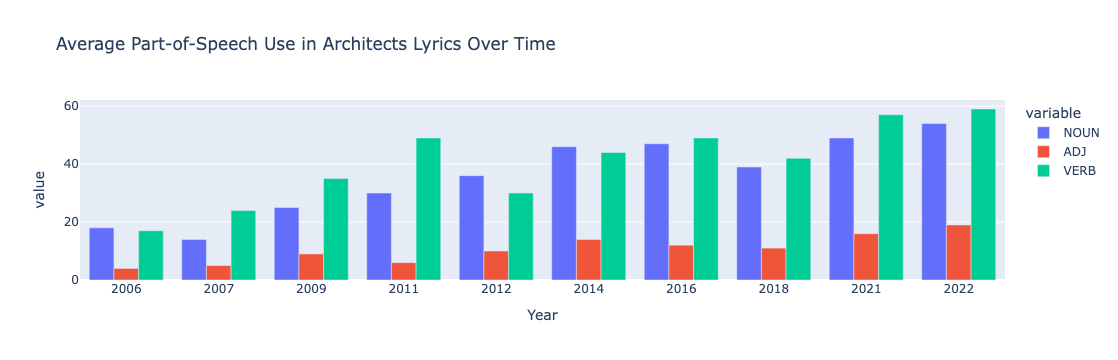

In [200]:
fig = px.bar(average_pos_df, x="Year", y=["NOUN", 'ADJ', "VERB"], 
             title="Average Part-of-Speech Use in Architects Lyrics Over Time", 
             barmode='group')

# Convert x-axis to categorical to show only those years present in the data.
fig.update_xaxes(type='category')

fig.show()

A quick investigation of the individual lyric files, however, reveals that the earlier lyrics were far shorter compared to the later albums. This is also shown by calculating the average token count of the lyrics per year:

In [232]:
# Create a new column for token count.
final_lyrics_df['token_count'] = final_lyrics_df['tokens'].apply(len)

# Group by year and calculate the average token count.
average_token_count = final_lyrics_df.groupby('year')['token_count'].mean().round().reset_index()
average_token_count

,year,token_count
0,2006,95.0
1,2007,128.0
2,2009,198.0
3,2011,253.0
4,2012,173.0
5,2014,260.0
6,2016,282.0
7,2018,236.0
8,2021,302.0
9,2022,329.0


Here we see that the average number of tokens per song was 95 in 2006 and 329 in 2022, meaning that the lyrics have more than tripled in length over time. This has a significant effect on the raw counts of parts-of-speech, skewing the initial interpretation. For deeper analysis, it's crucial to take text length into account by normalising the data.